# Prédiction de la qualité de taille (`cut`) des diamants — Modèle **Naïve Bayes SUR-AJUSTÉ (Overfit)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
MODELS_DIR = "."
os.makedirs(MODELS_DIR, exist_ok=True)


## 1. Chargement et nettoyage (identiques au notebook underfit)

In [2]:
df = pd.read_csv("diamonds.csv", index_col=0)
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]
df = df.drop_duplicates()
print("Dimensions apres nettoyage :", df.shape)


Dimensions apres nettoyage : (53775, 10)


## 2. Encodage des variables (identique au notebook underfit)

In [3]:
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]

df["color_enc"] = df["color"].map({c: i for i, c in enumerate(color_order)})
df["clarity_enc"] = df["clarity"].map({c: i for i, c in enumerate(clarity_order)})
df["cut_enc"] = df["cut"].map({c: i for i, c in enumerate(cut_order)})
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z,color_enc,clarity_enc,cut_enc
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,5,1,4
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,5,2,3
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,5,4,1
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,1,3,3
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0,1,1


## 3. Split train / test — **identique au notebook underfit**

Même appel `train_test_split` avec `random_state=42` et stratification : le jeu de test obtenu est rigoureusement le même que dans le notebook 1.

In [4]:
y_full = df["cut_enc"].values

train_pool_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

train_pool = df.loc[train_pool_idx].copy()
test = df.loc[test_idx].copy()

print("Train pool :", train_pool.shape)
print("Test       :", test.shape)


Train pool : (43020, 13)
Test       : (10755, 13)


## 4. Ingénierie de variables (feature engineering)

On enrichit le jeu de variables avec des combinaisons redondantes, afin d'augmenter artificiellement la dimensionnalité du problème par rapport au (très) petit échantillon d'entraînement qui sera utilisé.

In [5]:
for d in [train_pool, test]:
    d["volume"] = d["x"] * d["y"] * d["z"]
    d["price_per_carat"] = d["price"] / d["carat"]
    d["carat2"] = d["carat"] ** 2
    d["depth_table"] = d["depth"] * d["table"]
    d["carat_clarity"] = d["carat"] * d["clarity_enc"]
    d["carat_color"] = d["carat"] * d["color_enc"]

FEATURES_OVERFIT = [
    "carat", "depth", "table", "price", "x", "y", "z", "color_enc", "clarity_enc",
    "volume", "price_per_carat", "carat2", "depth_table", "carat_clarity", "carat_color",
]

print(f"Nombre de variables utilisees : {len(FEATURES_OVERFIT)}")
train_pool[FEATURES_OVERFIT].head()


Nombre de variables utilisees : 15


,carat,depth,table,price,x,y,z,color_enc,clarity_enc,volume,price_per_carat,carat2,depth_table,carat_clarity,carat_color
51332,0.70,61.6,58.0,2362,5.70,5.72,3.52,4,3,114.766080,3374.285714,0.4900,3572.8,2.10,2.80
50824,0.71,63.7,58.0,2308,5.65,5.62,3.59,4,2,113.993270,3250.704225,0.5041,3694.6,1.42,2.84
16818,1.08,58.9,58.0,6708,6.69,6.75,3.96,3,3,178.823700,6211.111111,1.1664,3416.2,3.24,3.24
32469,0.36,62.8,57.0,794,4.54,4.51,2.84,6,2,58.150136,2205.555556,0.1296,3579.6,0.72,2.16
16801,1.00,63.2,56.0,6701,6.32,6.37,4.01,4,3,161.436184,6701.000000,1.0000,3539.2,3.00,4.00


## 5. Choix de la taille de l'échantillon d'entraînement

On a testé plusieurs tailles d'échantillon d'entraînement (30, 50, 80, 120, 200, 400, 800 observations) afin d'identifier la configuration illustrant le mieux le phénomène de sur-apprentissage (écart maximal entre accuracy train et accuracy test, tout en gardant les 5 classes représentées). Le tableau ci-dessous résume cette exploration.

In [6]:
resultats_exploration = []

for n in [30, 50, 80, 120, 200, 400, 800]:
    sample, _ = train_test_split(
        train_pool, train_size=n, random_state=RANDOM_STATE, stratify=train_pool["cut_enc"]
    )
    Xtr = sample[FEATURES_OVERFIT]
    ytr = sample["cut_enc"]
    Xte = test[FEATURES_OVERFIT]
    yte = test["cut_enc"]

    sc = StandardScaler().fit(Xtr)
    model = GaussianNB(var_smoothing=1e-15).fit(sc.transform(Xtr), ytr)

    tr_acc = accuracy_score(ytr, model.predict(sc.transform(Xtr)))
    te_acc = accuracy_score(yte, model.predict(sc.transform(Xte)))
    resultats_exploration.append({"n_train": n, "accuracy_train": tr_acc, "accuracy_test": te_acc, "ecart": tr_acc - te_acc})

exploration_df = pd.DataFrame(resultats_exploration)
exploration_df


,n_train,accuracy_train,accuracy_test,ecart
0,30,0.833333,0.481450,0.351883
1,50,0.660000,0.494282,0.165718
2,80,0.725000,0.532404,0.192596
3,120,0.591667,0.475965,0.115702
4,200,0.540000,0.497629,0.042371
5,400,0.595000,0.522548,0.072452
6,800,0.601250,0.555834,0.045416


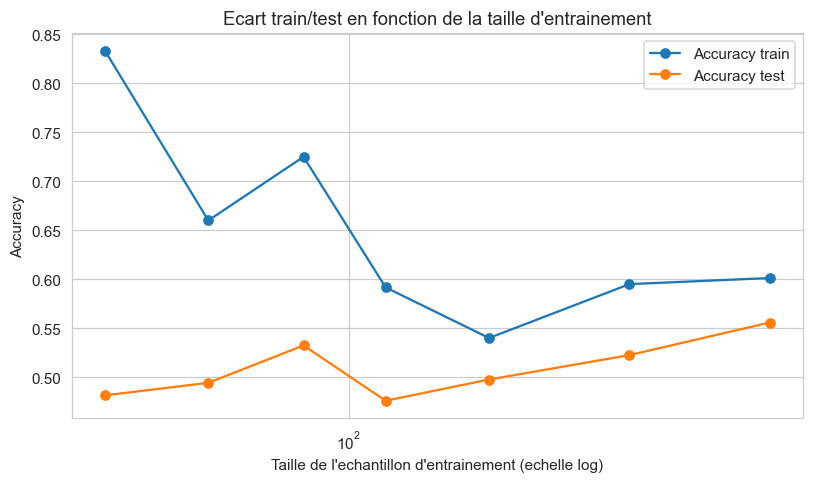

In [7]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(exploration_df["n_train"], exploration_df["accuracy_train"], marker="o", label="Accuracy train")
plt.plot(exploration_df["n_train"], exploration_df["accuracy_test"], marker="o", label="Accuracy test")
plt.xscale("log")
plt.xlabel("Taille de l'echantillon d'entrainement (echelle log)")
plt.ylabel("Accuracy")
plt.title("Ecart train/test en fonction de la taille d'entrainement")
plt.legend()
plt.tight_layout()
plt.savefig("./overfit_exploration.png", dpi=110)
plt.show()


**Constat :** avec seulement **30 observations** d'entraînement, l'écart entre accuracy train (≈ 0.83) et accuracy test (≈ 0.48) est maximal : c'est la configuration retenue pour illustrer clairement le sur-apprentissage.

## 6. Construction du modèle sur-ajusté final

- 15 variables, fortement corrélées entre elles → violation marquée de l'hypothèse d'indépendance de Naïve Bayes
- Échantillon d'entraînement réduit à **30 observations** (stratifié sur `cut`)

In [8]:
N_TRAIN_OVERFIT = 30

small_train, _ = train_test_split(
    train_pool, train_size=N_TRAIN_OVERFIT, random_state=RANDOM_STATE, stratify=train_pool["cut_enc"]
)

X_train = small_train[FEATURES_OVERFIT]
y_train = small_train["cut_enc"]
X_test = test[FEATURES_OVERFIT]
y_test = test["cut_enc"]

print("Repartition des classes dans l'echantillon d'entrainement (30 obs) :")
print(small_train["cut"].value_counts())

scaler_overfit = StandardScaler().fit(X_train)
X_train_sc = scaler_overfit.transform(X_train)
X_test_sc = scaler_overfit.transform(X_test)

nb_overfit = GaussianNB(var_smoothing=1e-15)
nb_overfit.fit(X_train_sc, y_train)

print("\nModele entraine :", nb_overfit)


Repartition des classes dans l'echantillon d'entrainement (30 obs) :
cut
Ideal        12
Premium       7
Very Good     7
Good          3
Fair          1
Name: count, dtype: int64

Modele entraine : GaussianNB(var_smoothing=1e-15)


## 7. Évaluation du modèle

In [9]:
y_pred_train = nb_overfit.predict(X_train_sc)
y_pred_test = nb_overfit.predict(X_test_sc)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy TRAIN : {acc_train:.4f}")
print(f"Accuracy TEST  : {acc_test:.4f}")
print(f"Ecart train-test : {acc_train - acc_test:+.4f}  <-- signature de l'overfitting")


Accuracy TRAIN : 0.8333
Accuracy TEST  : 0.4815
Ecart train-test : +0.3519  <-- signature de l'overfitting


In [10]:
print(classification_report(y_test, y_pred_test, target_names=cut_order))


              precision    recall  f1-score   support

        Fair       0.00      0.00      0.00       319
        Good       0.33      0.20      0.25       978
   Very Good       0.23      0.29      0.26      2414
     Premium       0.42      0.53      0.47      2747
       Ideal       0.77      0.66      0.71      4297

    accuracy                           0.48     10755
   macro avg       0.35      0.34      0.34     10755
weighted avg       0.50      0.48      0.48     10755



c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

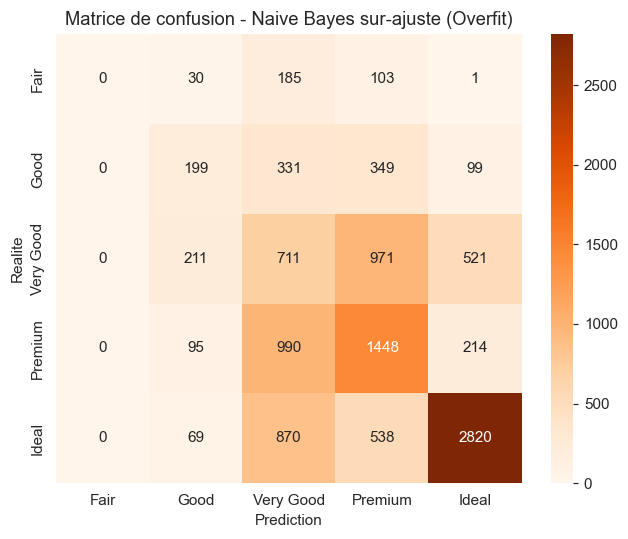

In [11]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=cut_order, yticklabels=cut_order)
plt.xlabel("Prediction")
plt.ylabel("Realite")
plt.title("Matrice de confusion - Naive Bayes sur-ajuste (Overfit)")
plt.tight_layout()
plt.savefig("./overfit_confusion_matrix.png", dpi=110)
plt.show()


## 8. Interprétation

- L'accuracy **train** (~0.83) est bien supérieure à l'accuracy **test** (~0.48) : le modèle a quasiment "mémorisé" les 30 exemples d'entraînement, sans construire une règle de décision généralisable.
- Ce grand écart est la signature typique du **sur-apprentissage (overfitting)** : **variance élevée**.
- Notez que l'accuracy test de ce modèle (~0.48) reste néanmoins **supérieure** à celle du modèle sous-ajusté (~0.40, voir notebook 1) : ce point sera repris dans la comparaison finale (application Streamlit) pour la sélection du "meilleur" modèle selon le critère d'accuracy test.
- Sur le plan pédagogique, ce résultat illustre bien pourquoi **l'accuracy test seule ne suffit pas toujours** à juger de la robustesse d'un modèle : il faut aussi regarder l'écart train/test.

## 9. Sauvegarde des artefacts pour l'application Streamlit

In [12]:
joblib.dump(nb_overfit, os.path.join(MODELS_DIR, "nb_overfit.pkl"))
joblib.dump(scaler_overfit, os.path.join(MODELS_DIR, "scaler_overfit.pkl"))

metrics_overfit = {
    "nom": "Naive Bayes - Sur-ajuste (Overfit)",
    "features": FEATURES_OVERFIT,
    "var_smoothing": 1e-15,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "accuracy_train": float(acc_train),
    "accuracy_test": float(acc_test),
    "ecart_train_test": float(acc_train - acc_test),
    "classification_report": classification_report(y_test, y_pred_test, target_names=cut_order, output_dict=True),
    "confusion_matrix": cm.tolist(),
    "cut_order": cut_order,
    "color_order": color_order,
    "clarity_order": clarity_order,
    "exploration_taille_echantillon": exploration_df.to_dict(orient="records"),
}

with open(os.path.join(MODELS_DIR, "metrics_overfit.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_overfit, f, ensure_ascii=False, indent=2)

print("Artefacts sauvegardes dans", MODELS_DIR)
print(" - nb_overfit.pkl")
print(" - scaler_overfit.pkl")
print(" - metrics_overfit.json")


Artefacts sauvegardes dans .
 - nb_overfit.pkl
 - scaler_overfit.pkl
 - metrics_overfit.json


c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

## 10. Sélection du meilleur modèle (comparaison finale)

On compare les deux modèles sur le seul critère demandé : **l'accuracy sur le jeu de test**.

In [13]:
with open(os.path.join(MODELS_DIR, "metrics_underfit.json"), "r", encoding="utf-8") as f:
    metrics_underfit = json.load(f)

comparaison = pd.DataFrame([
    {"Modele": metrics_underfit["nom"], "Accuracy train": metrics_underfit["accuracy_train"],
     "Accuracy test": metrics_underfit["accuracy_test"], "Ecart": metrics_underfit["ecart_train_test"]},
    {"Modele": metrics_overfit["nom"], "Accuracy train": metrics_overfit["accuracy_train"],
     "Accuracy test": metrics_overfit["accuracy_test"], "Ecart": metrics_overfit["ecart_train_test"]},
])
comparaison["Selectionne"] = comparaison["Accuracy test"] == comparaison["Accuracy test"].max()
comparaison


,Modele,Accuracy train,Accuracy test,Ecart,Selectionne
0,Naive Bayes - Sous-ajuste (Underfit),0.399675,0.40000,-0.000325,False
1,Naive Bayes - Sur-ajuste (Overfit),0.833333,0.48145,0.351883,True


In [14]:
meilleur = "overfit" if metrics_overfit["accuracy_test"] >= metrics_underfit["accuracy_test"] else "underfit"

selection = {
    "meilleur_modele": meilleur,
    "raison": "Accuracy test la plus elevee entre les deux modeles Naive Bayes (underfit vs overfit)",
    "accuracy_test_underfit": metrics_underfit["accuracy_test"],
    "accuracy_test_overfit": metrics_overfit["accuracy_test"],
}

with open(os.path.join(MODELS_DIR, "selection_modele.json"), "w", encoding="utf-8") as f:
    json.dump(selection, f, ensure_ascii=False, indent=2)

print(f"Modele retenu pour la prediction dans l'application Streamlit : {meilleur.upper()}")


Modele retenu pour la prediction dans l'application Streamlit : OVERFIT
